# Lecture 3 — From phase to collective synchronization


In [1]:
# Housekeeping code...
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import Video

if Path("../media").exists():
    MEDIA = Path("../media")
elif Path("media").exists():
    MEDIA = Path("media")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

TAU = 2 * np.pi
BLUE = "#3B6FB6"
ORANGE = "#D97706"
GOLD = "#C9A227"
PINK = "#B64E77"
OLIVE = "#718355"
INK = "#263238"
GREY = "#9AA0A6"
LIGHT = "#E7EAED"
rng = np.random.default_rng(567)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

def movie(filename, width=520):
    return Video(
        str(MEDIA / filename),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

def wrap_phase(theta):
    return (np.asarray(theta) + np.pi) % TAU - np.pi

def order_parameter(theta, axis=-1):
    return np.mean(np.exp(1j * np.asarray(theta)), axis=axis)

def kuramoto_rhs(theta, omega, coupling):
    mean_field = order_parameter(theta)
    return omega + coupling * np.imag(mean_field * np.exp(-1j * theta))

def simulate_kuramoto(
    omega, coupling, theta0, *, t_end, dt=0.01, save_every=1
):
    omega = np.asarray(omega, dtype=float)
    theta = np.asarray(theta0, dtype=float).copy()
    if omega.ndim != 1 or theta.shape != omega.shape:
        raise ValueError("omega and theta0 must have the same one-dimensional shape")
    n_steps = int(np.ceil(t_end / dt))
    save_steps = np.arange(0, n_steps + 1, save_every)
    times = np.empty(save_steps.size)
    phases = np.empty((save_steps.size, omega.size))
    times[0], phases[0] = 0.0, theta
    save_index = 1

    for step in range(1, n_steps + 1):
        slope = kuramoto_rhs(theta, omega, coupling)
        midpoint = theta + 0.5 * dt * slope
        theta += dt * kuramoto_rhs(midpoint, omega, coupling)
        if save_index < save_steps.size and step == save_steps[save_index]:
            times[save_index] = step * dt
            phases[save_index] = theta
            save_index += 1
    return times, phases

def observed_frequencies(times, phases, tail_fraction=0.4):
    start = int((1 - tail_fraction) * times.size)
    centered_time = times[start:] - times[start:].mean()
    centered_phase = phases[start:] - phases[start:].mean(axis=0)
    return centered_time @ centered_phase / (centered_time @ centered_time)

def colored_line(ax, x, y, phase, linewidth=3):
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    collection = LineCollection(
        segments,
        cmap="twilight",
        norm=plt.Normalize(0, TAU),
        linewidth=linewidth,
    )
    collection.set_array(np.mod(phase[:-1], TAU))
    ax.add_collection(collection)
    ax.autoscale_view()

def draw_phase_cloud(ax, phases, color=BLUE, title=None):
    phases = np.asarray(phases)
    circle = np.linspace(0, TAU, 400)
    ax.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=2)
    ax.scatter(
        np.cos(phases),
        np.sin(phases),
        s=28,
        facecolor=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )
    z = order_parameter(phases)
    if abs(z) > 1e-3:
        ax.arrow(
            0,
            0,
            z.real,
            z.imag,
            width=0.015,
            head_width=0.10,
            length_includes_head=True,
            color=ORANGE,
            zorder=4,
        )
    ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15))
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title)
    ax.text(0, -1.28, rf"$R={abs(z):.2f}$", ha="center")


## A gait is a phase-locked state

Four limb cycles. One stable pattern of phase differences.


In [2]:
movie("mouse-running.mp4")


## Different systems, one repeating coordinate


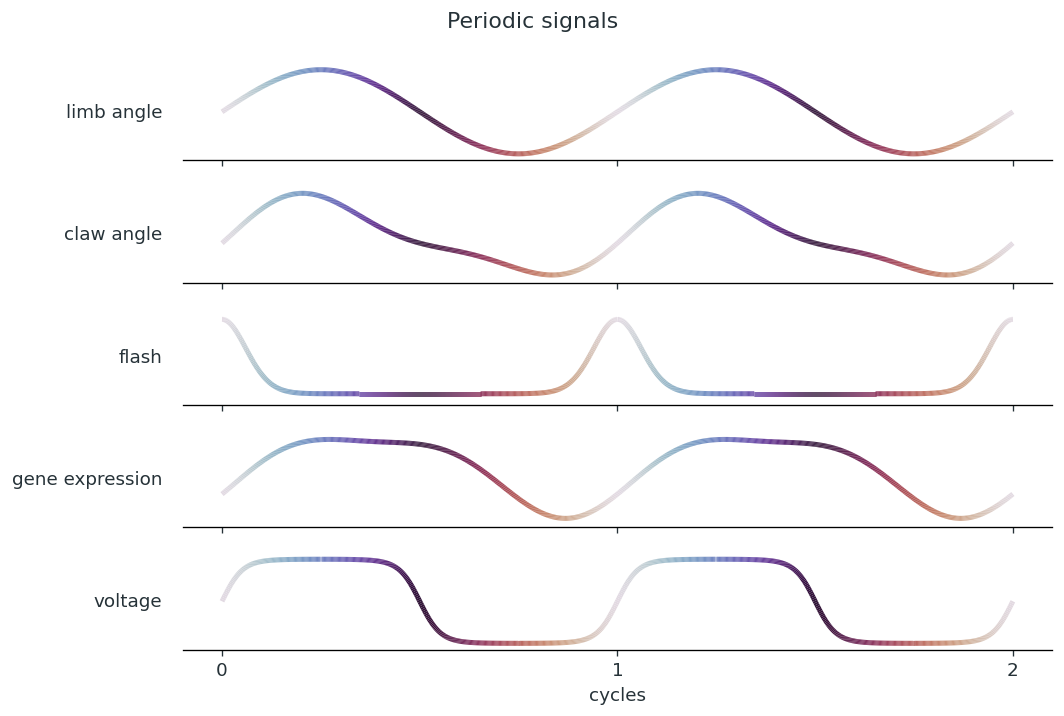

In [3]:
phase = np.linspace(0, 4 * np.pi, 900)
time = phase / (2 * np.pi)
signals = [
    ("limb angle", np.sin(phase)),
    ("claw angle", 0.72 * np.sin(phase) + 0.22 * np.sin(2 * phase - 0.5)),
    ("flash", np.exp(7 * (np.cos(phase) - 1))),
    ("gene expression", 0.65 * np.sin(phase - 0.7) + 0.18 * np.sin(2 * phase)),
    ("voltage", np.tanh(3 * np.sin(phase))),
]

fig, axes = plt.subplots(len(signals), 1, figsize=(9, 6), sharex=True)
for ax, (label, signal) in zip(axes, signals):
    colored_line(ax, time, signal, phase)
    ax.set_ylim(signal.min() - 0.15, signal.max() + 0.15)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", labelpad=12)
    ax.spines["left"].set_visible(False)

axes[-1].set(xlabel="cycles", xticks=[0, 1, 2])
fig.suptitle("Periodic signals", y=0.99)
fig.tight_layout()
plt.show()


## Phase

$$
\theta\in[0,2\pi),
\qquad
\theta\equiv\theta+2\pi
$$

$$
\dot\theta=\omega,
\qquad
\omega=\frac{2\pi}{T}
$$


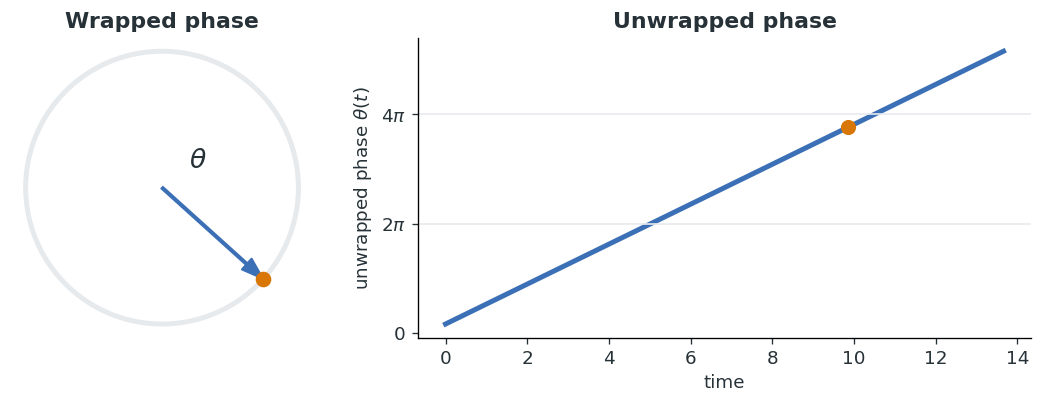

In [4]:
omega = 1.15
t = np.linspace(0, 2.5 * TAU / omega, 500)
theta = omega * t + 0.5
now = 0.72 * len(t)
now = int(now)

fig, (ax_circle, ax_time) = plt.subplots(
    1, 2, figsize=(9, 3.5), gridspec_kw={"width_ratios": [1, 1.8]}
)

circle = np.linspace(0, TAU, 400)
ax_circle.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=3)
ax_circle.arrow(
    0, 0, np.cos(theta[now]), np.sin(theta[now]),
    width=0.018, head_width=0.11, color=BLUE, length_includes_head=True
)
ax_circle.scatter(
    np.cos(theta[now]), np.sin(theta[now]), s=70, color=ORANGE, zorder=4
)
ax_circle.text(0.2, 0.15, r"$\theta$", fontsize=16)
ax_circle.set_aspect("equal")
ax_circle.axis("off")
ax_circle.set_title("Wrapped phase")

ax_time.plot(t, theta, color=BLUE, lw=3)
ax_time.scatter(t[now], theta[now], s=65, color=ORANGE, zorder=4)
for level in [TAU, 2 * TAU]:
    ax_time.axhline(level, color=LIGHT, lw=1)
ax_time.set(
    xlabel="time",
    ylabel=r"unwrapped phase $\theta(t)$",
    yticks=[0, TAU, 2 * TAU],
    yticklabels=["0", r"$2\pi$", r"$4\pi$"],
    title="Unwrapped phase",
)

fig.tight_layout()
plt.show()


## Phase-difference coupling

$$
\dot\theta_i
=
\omega_i
+
\frac{K}{N}\sum_{j=1}^{N}
H(\theta_j-\theta_i)
$$

$$
H(\varphi+2\pi)=H(\varphi)
$$


## First-harmonic approximation

$$
H(-\varphi)=-H(\varphi)
$$

$$
H(\varphi)
=
\sum_{n=1}^{\infty} b_n\sin(n\varphi)
\qquad\longrightarrow\qquad
H(\varphi)\approx b_1\sin\varphi
$$


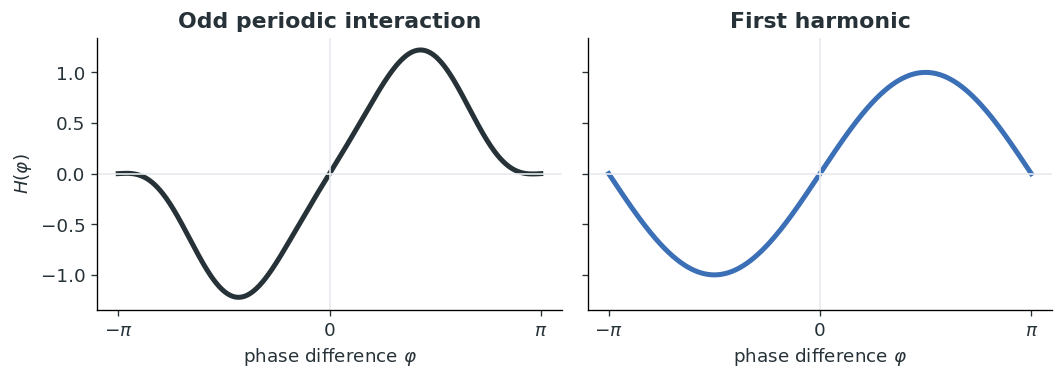

In [5]:
phi = np.linspace(-np.pi, np.pi, 600)
interaction = np.sin(phi) + 0.28 * np.sin(2 * phi) - 0.16 * np.sin(3 * phi)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), sharey=True)
axes[0].plot(phi, interaction, color=INK, lw=3)
axes[0].axhline(0, color=LIGHT, lw=1)
axes[0].axvline(0, color=LIGHT, lw=1)
axes[0].set_title("Odd periodic interaction")

axes[1].plot(phi, np.sin(phi), color=BLUE, lw=3)
axes[1].axhline(0, color=LIGHT, lw=1)
axes[1].axvline(0, color=LIGHT, lw=1)
axes[1].set_title("First harmonic")

for ax in axes:
    ax.set(
        xlabel=r"phase difference $\varphi$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
    )
axes[0].set_ylabel(r"$H(\varphi)$")
fig.tight_layout()
plt.show()


## The Kuramoto model

$$
\boxed{
\dot\theta_i
=
\omega_i
+
\frac{K}{N}\sum_{j=1}^{N}
\sin(\theta_j-\theta_i)
}
$$

$K>0$: small phase differences between identical oscillators shrink.


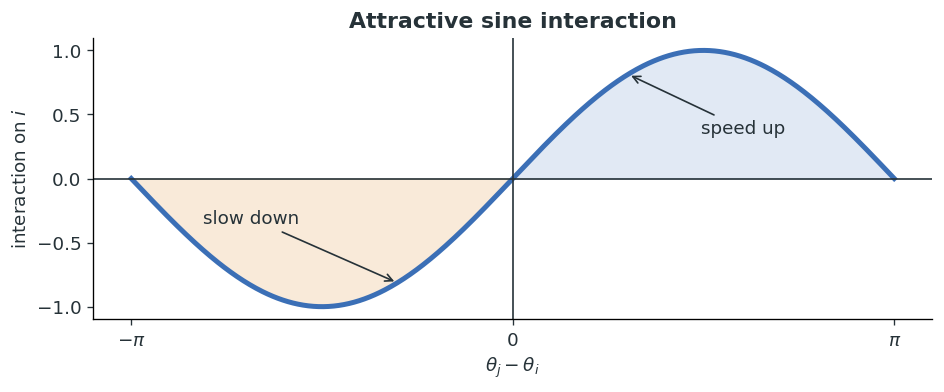

In [6]:
phi = np.linspace(-np.pi, np.pi, 600)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(phi, np.sin(phi), color=BLUE, lw=3)
ax.fill_between(
    phi, 0, np.sin(phi),
    where=(phi > 0), color=BLUE, alpha=0.15
)
ax.fill_between(
    phi, 0, np.sin(phi),
    where=(phi < 0), color=ORANGE, alpha=0.15
)
ax.axhline(0, color=INK, lw=1)
ax.axvline(0, color=INK, lw=1)
ax.annotate("speed up", (0.95, np.sin(0.95)), xytext=(1.55, 0.35),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.annotate("slow down", (-0.95, np.sin(-0.95)), xytext=(-2.55, -0.35),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.set(
    xlabel=r"$\theta_j-\theta_i$",
    ylabel=r"interaction on $i$",
    xticks=[-np.pi, 0, np.pi],
    xticklabels=[r"$-\pi$", "0", r"$\pi$"],
    title="Attractive sine interaction",
)
fig.tight_layout()
plt.show()


## Two coupled oscillators

$$
\dot\theta_1
=
\omega_1+\frac{K}{2}\sin(\theta_2-\theta_1)
$$

$$
\dot\theta_2
=
\omega_2+\frac{K}{2}\sin(\theta_1-\theta_2)
$$


## Mean and relative phase

$$
\bar\theta=\frac{\theta_1+\theta_2}{2},
\qquad
\Delta=\theta_2-\theta_1
$$

$$
\bar\omega=\frac{\omega_1+\omega_2}{2},
\qquad
\Delta\omega=\omega_2-\omega_1
$$


## Relative-phase dynamics

$$
\dot{\bar\theta}=\bar\omega
$$

$$
\boxed{
\dot\Delta=\Delta\omega-K\sin\Delta
}
$$

All synchronization dynamics are in $\Delta$.


> ### Prediction
>
> For which values of $K$ can $\Delta$ stop moving?


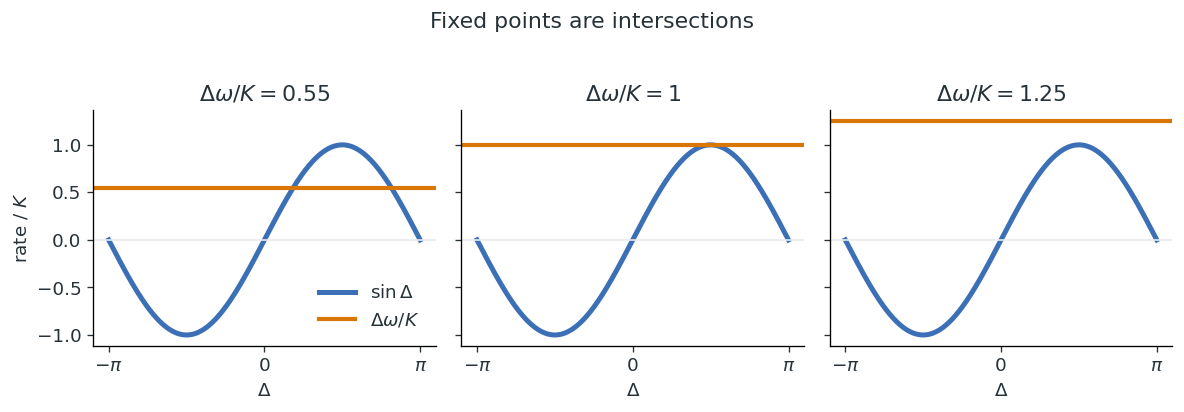

In [7]:
delta = np.linspace(-np.pi, np.pi, 700)
mismatch_ratios = [0.55, 1.0, 1.25]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), sharey=True)
for ax, ratio in zip(axes, mismatch_ratios):
    ax.plot(delta, np.sin(delta), color=BLUE, lw=3, label=r"$\sin\Delta$")
    ax.axhline(ratio, color=ORANGE, lw=2.5, label=r"$\Delta\omega/K$")
    ax.axhline(0, color=LIGHT, lw=1)
    ax.set(
        xlabel=r"$\Delta$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        title=rf"$\Delta\omega/K={ratio:g}$",
    )
axes[0].set_ylabel("rate / $K$")
axes[0].legend(frameon=False, loc="lower right")
fig.suptitle("Fixed points are intersections", y=1.03)
fig.tight_layout()
plt.show()


## Phase locking

$$
\dot\Delta=0
\qquad\Longrightarrow\qquad
\sin\Delta^*=\frac{\Delta\omega}{K}
$$

$$
\boxed{|\Delta\omega|\le |K|}
$$


## Stability

$$
\left.
\frac{d\dot\Delta}{d\Delta}
\right|_{\Delta^*}
=
-K\cos\Delta^*
$$

For $K>0$:

$$
|\Delta^*|<\frac{\pi}{2}
\qquad\text{is stable.}
$$


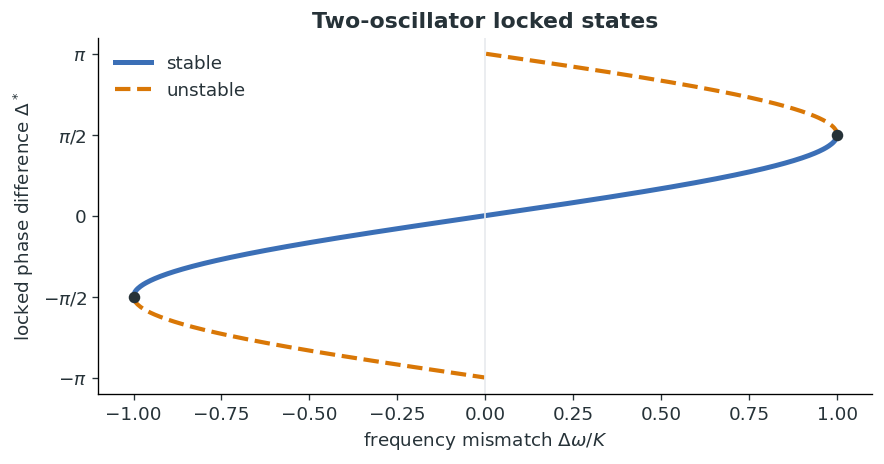

In [8]:
mismatch = np.linspace(-1, 1, 500)
stable = np.arcsin(mismatch)
unstable = wrap_phase(np.pi - stable)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(mismatch, stable, color=BLUE, lw=3, label="stable")
negative = mismatch < 0
positive = ~negative
ax.plot(
    mismatch[negative],
    unstable[negative],
    color=ORANGE,
    lw=2.5,
    ls="--",
    label="unstable",
)
ax.plot(
    mismatch[positive],
    unstable[positive],
    color=ORANGE,
    lw=2.5,
    ls="--",
)
ax.scatter([-1, 1], [-np.pi / 2, np.pi / 2], color=INK, s=35, zorder=4)
ax.axvline(0, color=LIGHT, lw=1)
ax.set(
    xlabel=r"frequency mismatch $\Delta\omega/K$",
    ylabel=r"locked phase difference $\Delta^*$",
    yticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    yticklabels=[r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"],
    title="Two-oscillator locked states",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Locked frequency

$$
\dot\theta_1=\dot\theta_2=\bar\omega
=
\frac{\omega_1+\omega_2}{2}
$$

Same frequency. Fixed phase difference.


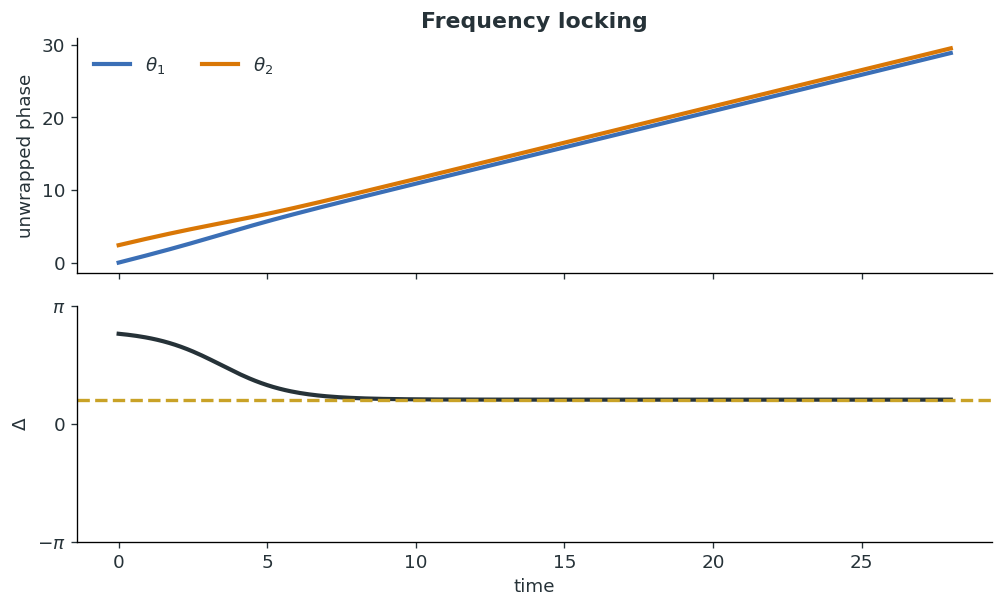

In [9]:
pair_omega = np.array([0.70, 1.30])
pair_K = 1.0
pair_t, pair_theta = simulate_kuramoto(
    pair_omega,
    pair_K,
    theta0=np.array([0.0, 2.4]),
    t_end=28,
    dt=0.01,
    save_every=10,
)
pair_delta = wrap_phase(pair_theta[:, 1] - pair_theta[:, 0])
stable_delta = np.arcsin((pair_omega[1] - pair_omega[0]) / pair_K)

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5.2), sharex=True)
axes[0].plot(pair_t, pair_theta[:, 0], color=BLUE, lw=2.5, label=r"$\theta_1$")
axes[0].plot(pair_t, pair_theta[:, 1], color=ORANGE, lw=2.5, label=r"$\theta_2$")
axes[0].set(ylabel="unwrapped phase", title="Frequency locking")
axes[0].legend(frameon=False, ncol=2)

axes[1].plot(pair_t, pair_delta, color=INK, lw=2.5)
axes[1].axhline(stable_delta, color=GOLD, lw=2, ls="--")
axes[1].set(
    xlabel="time",
    ylabel=r"$\Delta$",
    ylim=(-np.pi, np.pi),
    yticks=[-np.pi, 0, np.pi],
    yticklabels=[r"$-\pi$", "0", r"$\pi$"],
)
fig.tight_layout()
plt.show()


## Repulsive coupling

Identical oscillators:

$$
\dot\Delta=-K\sin\Delta
$$

$$
K>0:\ \Delta^*=0
\qquad
K<0:\ \Delta^*=\pi
$$


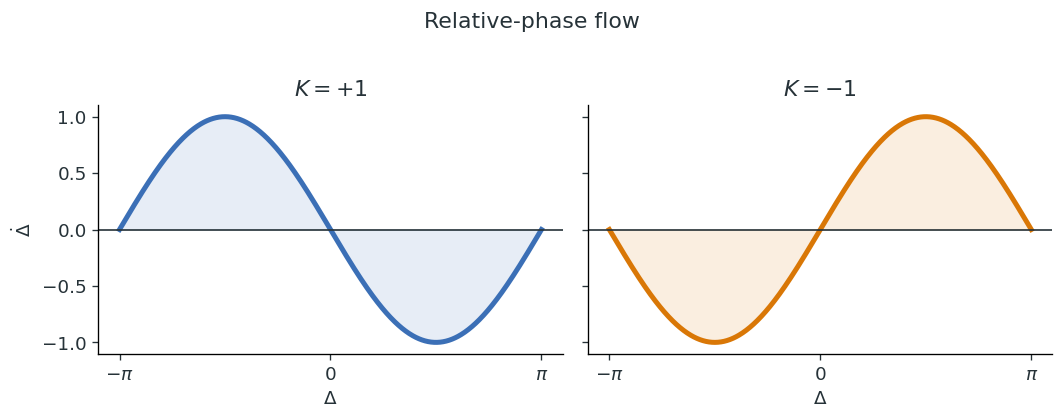

In [10]:
delta = np.linspace(-np.pi, np.pi, 700)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, K, color in zip(axes, [1, -1], [BLUE, ORANGE]):
    flow = -K * np.sin(delta)
    ax.plot(delta, flow, color=color, lw=3)
    ax.axhline(0, color=INK, lw=1)
    ax.fill_between(delta, 0, flow, color=color, alpha=0.12)
    ax.set(
        xlabel=r"$\Delta$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        title=rf"$K={K:+d}$",
    )
axes[0].set_ylabel(r"$\dot\Delta$")
fig.suptitle("Relative-phase flow", y=1.02)
fig.tight_layout()
plt.show()


## Tilted washboard

$$
\dot\Delta=-\frac{dV}{d\Delta}
$$

$$
V(\Delta)=-\Delta\omega\,\Delta-K\cos\Delta
$$


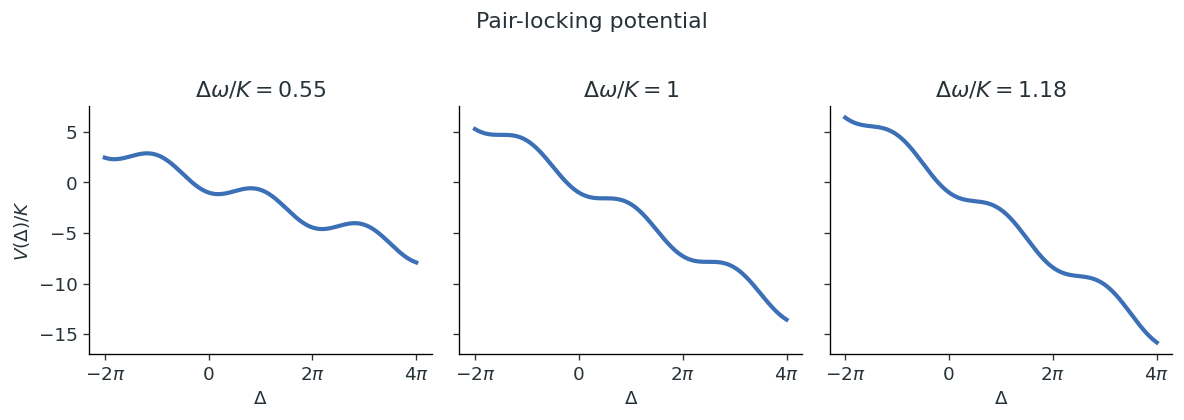

In [11]:
delta = np.linspace(-2 * np.pi, 4 * np.pi, 1000)
ratios = [0.55, 1.0, 1.18]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
for ax, ratio in zip(axes, ratios):
    potential = -ratio * delta - np.cos(delta)
    ax.plot(delta, potential, color=BLUE, lw=2.5)
    ax.set(
        xlabel=r"$\Delta$",
        xticks=[-2 * np.pi, 0, 2 * np.pi, 4 * np.pi],
        xticklabels=[r"$-2\pi$", "0", r"$2\pi$", r"$4\pi$"],
        title=rf"$\Delta\omega/K={ratio:g}$",
    )
axes[0].set_ylabel(r"$V(\Delta)/K$")
fig.suptitle("Pair-locking potential", y=1.02)
fig.tight_layout()
plt.show()


## Phase slips

$$
|\Delta\omega|>|K|
$$

No fixed point: $\Delta$ advances by $2\pi$ repeatedly.


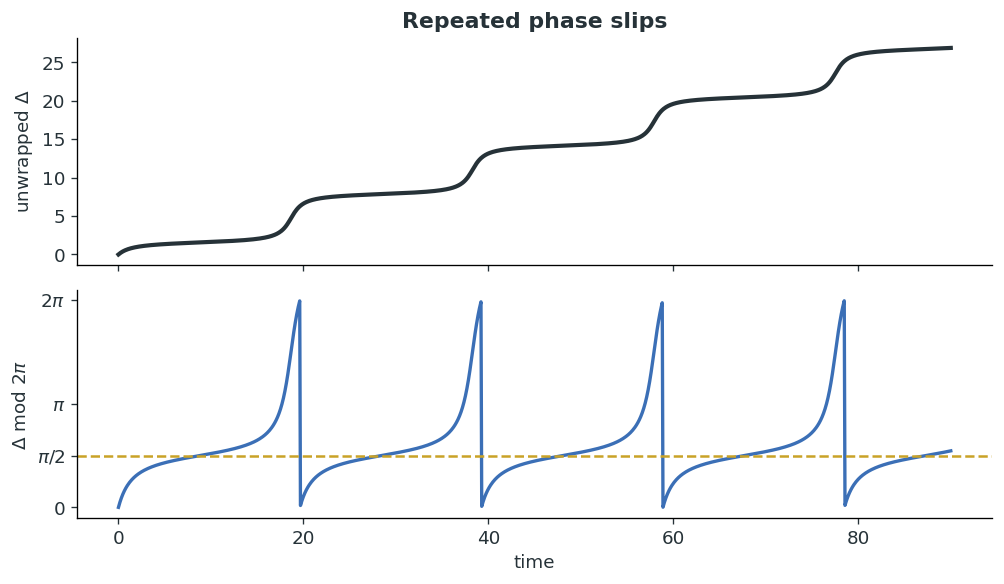

In [12]:
slip_omega = np.array([-0.525, 0.525])
slip_K = 1.0
slip_t, slip_theta = simulate_kuramoto(
    slip_omega,
    slip_K,
    theta0=np.array([0.0, 0.0]),
    t_end=90,
    dt=0.01,
    save_every=8,
)
slip_delta = slip_theta[:, 1] - slip_theta[:, 0]
slip_delta_wrapped = np.mod(slip_delta, TAU)

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5), sharex=True)
axes[0].plot(slip_t, slip_delta, color=INK, lw=2.5)
axes[0].set(ylabel=r"unwrapped $\Delta$", title="Repeated phase slips")

axes[1].plot(slip_t, slip_delta_wrapped, color=BLUE, lw=2)
axes[1].axhline(np.pi / 2, color=GOLD, lw=1.5, ls="--")
axes[1].set(
    xlabel="time",
    ylabel=r"$\Delta\ \mathrm{mod}\ 2\pi$",
    yticks=[0, np.pi / 2, np.pi, 2 * np.pi],
    yticklabels=["0", r"$\pi/2$", r"$\pi$", r"$2\pi$"],
)
fig.tight_layout()
plt.show()


## Slip rate

$$
T_{\mathrm{slip}}
=
\int_0^{2\pi}
\frac{d\Delta}{|\Delta\omega-K\sin\Delta|}
=
\frac{2\pi}{\sqrt{\Delta\omega^2-K^2}}
$$

$$
\boxed{
\langle\dot\Delta\rangle
=
\operatorname{sgn}(\Delta\omega)
\sqrt{\Delta\omega^2-K^2}
}
$$


## Saddle-node bifurcation on a circle

At $|\Delta\omega|=|K|$, the stable and unstable fixed points collide.

$$
T_{\mathrm{slip}}
\sim
\left(|\Delta\omega|-|K|\right)^{-1/2}
$$


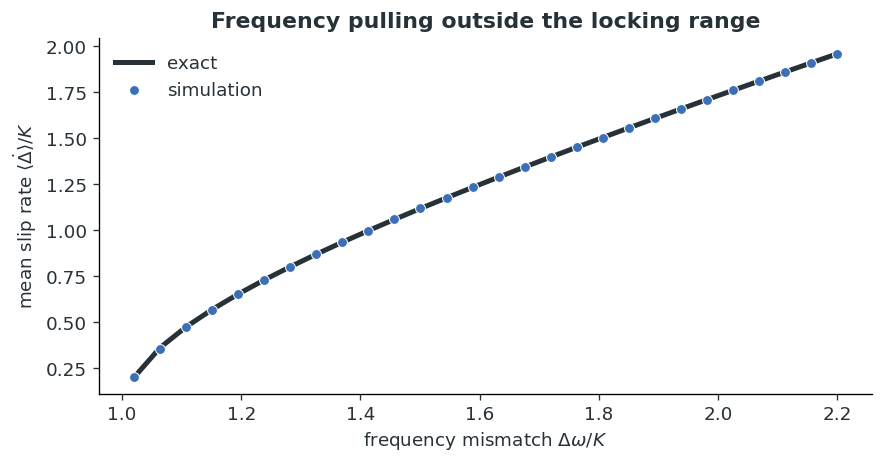

In [13]:
mismatch_values = np.linspace(1.02, 2.2, 28)
measured_rates = []

for mismatch_value in mismatch_values:
    times, phases = simulate_kuramoto(
        np.array([-mismatch_value / 2, mismatch_value / 2]),
        coupling=1.0,
        theta0=np.array([0.0, 0.0]),
        t_end=120,
        dt=0.02,
        save_every=10,
    )
    frequencies = observed_frequencies(times, phases, tail_fraction=0.6)
    measured_rates.append(frequencies[1] - frequencies[0])

exact_rates = np.sqrt(mismatch_values**2 - 1)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(mismatch_values, exact_rates, color=INK, lw=3, label="exact")
ax.scatter(
    mismatch_values,
    measured_rates,
    s=35,
    facecolor=BLUE,
    edgecolor="white",
    linewidth=0.6,
    label="simulation",
    zorder=3,
)
ax.set(
    xlabel=r"frequency mismatch $\Delta\omega/K$",
    ylabel=r"mean slip rate $\langle\dot\Delta\rangle/K$",
    title="Frequency pulling outside the locking range",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## $N$ coupled oscillators

$$
\dot\theta_i
=
\omega_i
+
\frac{K}{N}\sum_{j=1}^{N}
\sin(\theta_j-\theta_i)
$$

How do we summarize all $N$ phases?


## Complex order parameter

$$
e^{i\theta}=\cos\theta+i\sin\theta
$$

$$
Z=Re^{i\psi}
=
\frac{1}{N}\sum_{j=1}^{N}e^{i\theta_j}
$$

$R$: phase concentration  
$\psi$: collective phase


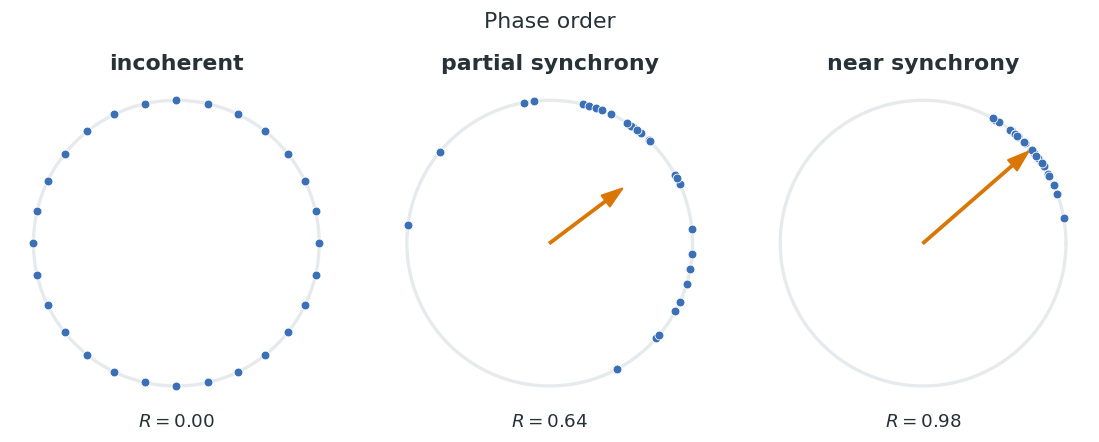

In [14]:
incoherent = np.linspace(0, TAU, 28, endpoint=False)
partial = rng.vonmises(mu=0.65, kappa=1.6, size=28)
synchronized = rng.vonmises(mu=0.65, kappa=18, size=28)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
for ax, phases, title in zip(
    axes,
    [incoherent, partial, synchronized],
    ["incoherent", "partial synchrony", "near synchrony"],
):
    draw_phase_cloud(ax, phases, title=title)
fig.suptitle("Phase order", y=1.02)
fig.tight_layout()
plt.show()


## $R$ does not specify the phase distribution


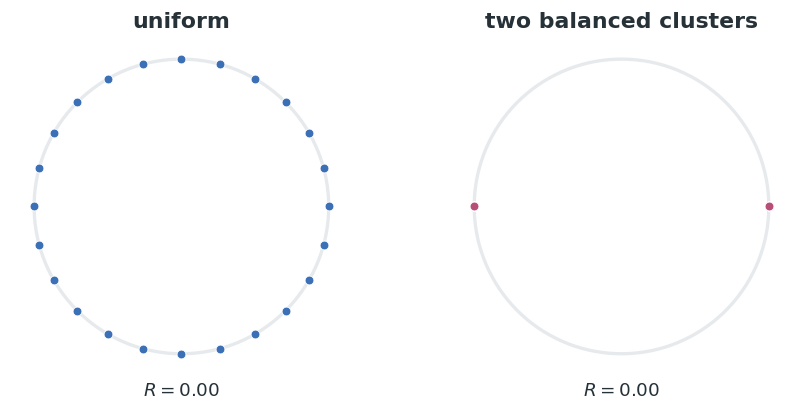

In [15]:
uniform_phases = np.linspace(0, TAU, 24, endpoint=False)
two_clusters = np.r_[np.zeros(12), np.full(12, np.pi)]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))
draw_phase_cloud(axes[0], uniform_phases, title="uniform")
draw_phase_cloud(axes[1], two_clusters, color=PINK, title="two balanced clusters")
fig.tight_layout()
plt.show()


## Mean-field reduction

$$
Ze^{-i\theta_i}
=
\frac{1}{N}\sum_j e^{i(\theta_j-\theta_i)}
$$

Take the imaginary part:

$$
\frac{1}{N}\sum_j\sin(\theta_j-\theta_i)
=
R\sin(\psi-\theta_i)
$$


## Self-generated mean field

$$
\boxed{
\dot\theta_i
=
\omega_i+KR\sin(\psi-\theta_i)
}
$$

The population creates the field that acts on every oscillator.


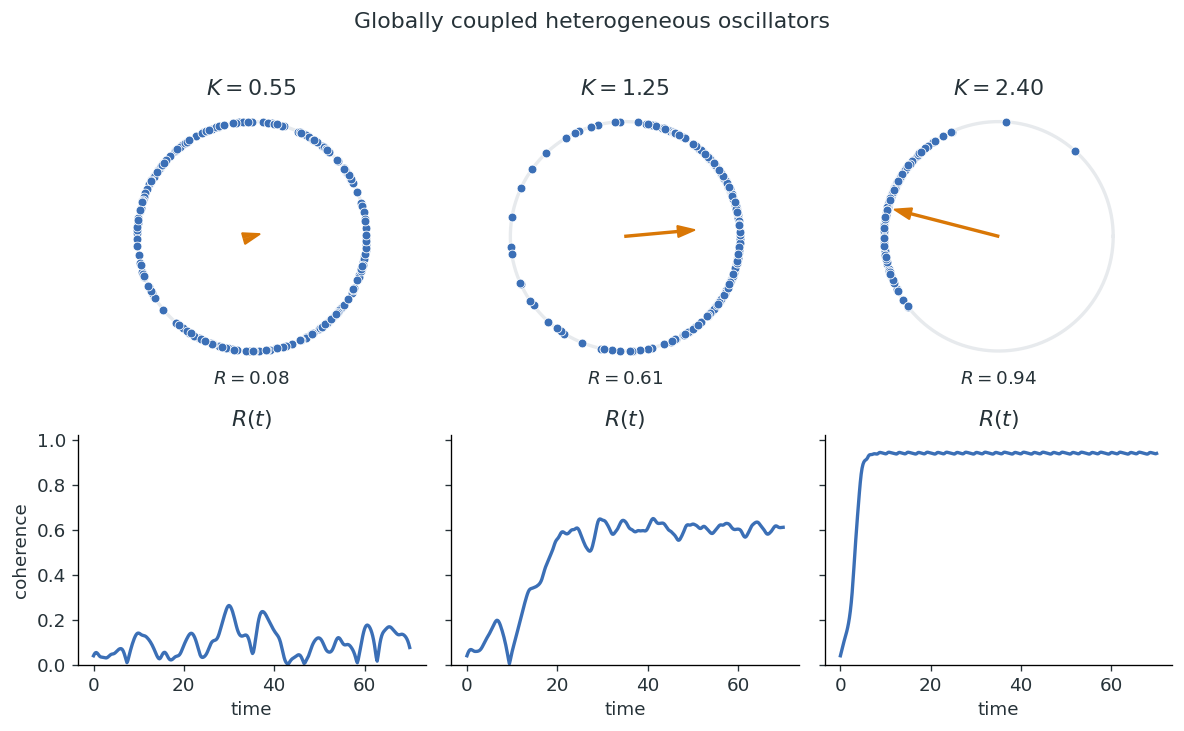

In [16]:
population_size = 240
positive_frequencies = np.abs(
    rng.normal(0, 0.70, population_size // 2)
)
natural_frequencies = np.r_[
    -positive_frequencies,
    positive_frequencies,
]
initial_phases = rng.uniform(-np.pi, np.pi, population_size)
coupling_values = [0.55, 1.25, 2.40]

fig, axes = plt.subplots(
    2, 3, figsize=(10, 6),
    gridspec_kw={"height_ratios": [1.15, 1]},
)

for column, coupling in enumerate(coupling_values):
    times, phases = simulate_kuramoto(
        natural_frequencies,
        coupling,
        initial_phases,
        t_end=70,
        dt=0.02,
        save_every=10,
    )
    coherence = np.abs(order_parameter(phases, axis=1))
    draw_phase_cloud(
        axes[0, column],
        wrap_phase(phases[-1]),
        title=rf"$K={coupling:.2f}$",
    )
    axes[1, column].plot(times, coherence, color=BLUE, lw=2)
    axes[1, column].set(
        xlabel="time",
        ylim=(0, 1.02),
        title=r"$R(t)$",
    )
    if column == 0:
        axes[1, column].set_ylabel("coherence")
    else:
        axes[1, column].set_yticklabels([])

fig.suptitle("Globally coupled heterogeneous oscillators", y=1.01)
fig.tight_layout()
plt.show()


## Finite-$N$ incoherent baseline

Independent uniform phases:

$$
\left\langle R^2\right\rangle
=
\frac{1}{N^2}
\sum_{j,k}
\left\langle e^{i(\theta_j-\theta_k)}\right\rangle
=
\frac{1}{N}
$$

$$
R_{\mathrm{rms}}=N^{-1/2}
$$


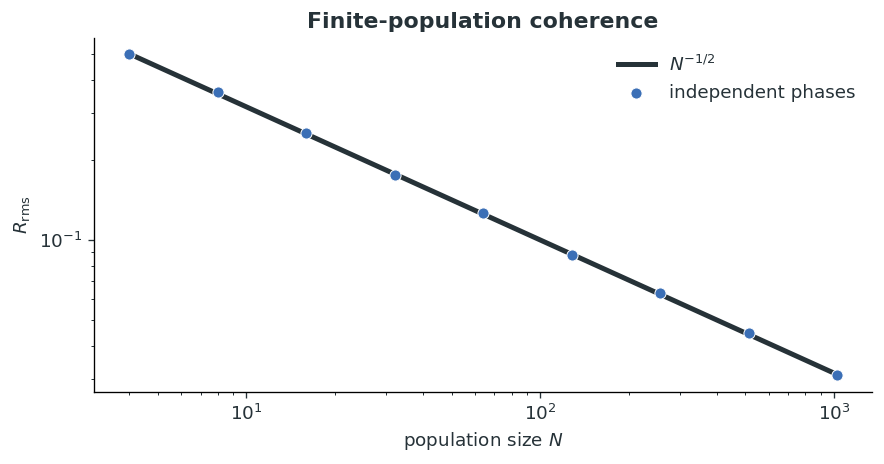

In [17]:
population_sizes = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
rms_coherence = []

for phase_count in population_sizes:
    random_phases = rng.uniform(
        0, TAU, size=(3000, phase_count)
    )
    coherence_squared = np.abs(
        order_parameter(random_phases, axis=1)
    ) ** 2
    rms_coherence.append(np.sqrt(coherence_squared.mean()))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.loglog(
    population_sizes,
    population_sizes ** -0.5,
    color=INK,
    lw=3,
    label=r"$N^{-1/2}$",
)
ax.scatter(
    population_sizes,
    rms_coherence,
    s=45,
    facecolor=BLUE,
    edgecolor="white",
    linewidth=0.6,
    label="independent phases",
    zorder=3,
)
ax.set(
    xlabel="population size $N$",
    ylabel=r"$R_{\mathrm{rms}}$",
    title="Finite-population coherence",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Rotating mean field

$$
\psi(t)=\Omega t,
\qquad
\phi_i=\theta_i-\psi,
\qquad
\nu_i=\omega_i-\Omega
$$

$$
\boxed{
\dot\phi_i
=
\nu_i-KR\sin\phi_i
}
$$

The same fixed-point problem as the oscillator pair.


## Locked core and drifting tails

$$
|\nu_i|\le KR
\qquad\Longrightarrow\qquad
\sin\phi_i^*=\frac{\nu_i}{KR}
$$

$$
|\nu_i|>KR
\qquad\Longrightarrow\qquad
\phi_i\ \text{drifts}
$$


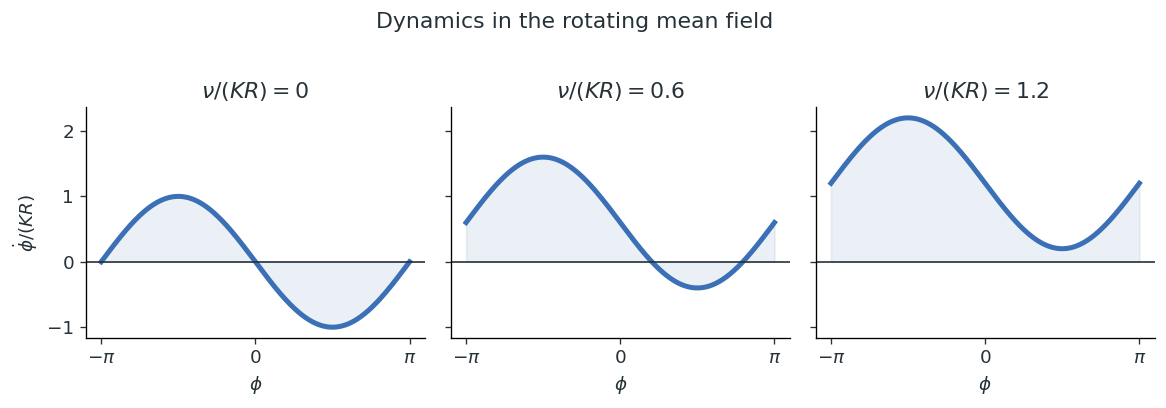

In [18]:
phi = np.linspace(-np.pi, np.pi, 700)
relative_frequencies = [0.0, 0.60, 1.20]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), sharey=True)
for ax, relative_frequency in zip(axes, relative_frequencies):
    flow = relative_frequency - np.sin(phi)
    ax.plot(phi, flow, color=BLUE, lw=3)
    ax.axhline(0, color=INK, lw=1)
    ax.fill_between(phi, 0, flow, color=BLUE, alpha=0.10)
    ax.set(
        xlabel=r"$\phi$",
        xticks=[-np.pi, 0, np.pi],
        xticklabels=[r"$-\pi$", "0", r"$\pi$"],
        title=rf"$\nu/(KR)={relative_frequency:g}$",
    )
axes[0].set_ylabel(r"$\dot\phi/(KR)$")
fig.suptitle("Dynamics in the rotating mean field", y=1.02)
fig.tight_layout()
plt.show()


## Stationary density of a drifting oscillator

$$
\rho(\phi\mid\nu)
=
\frac{\sqrt{\nu^2-(KR)^2}}
{2\pi|\nu-KR\sin\phi|}
$$

Slow phases are occupied more often.


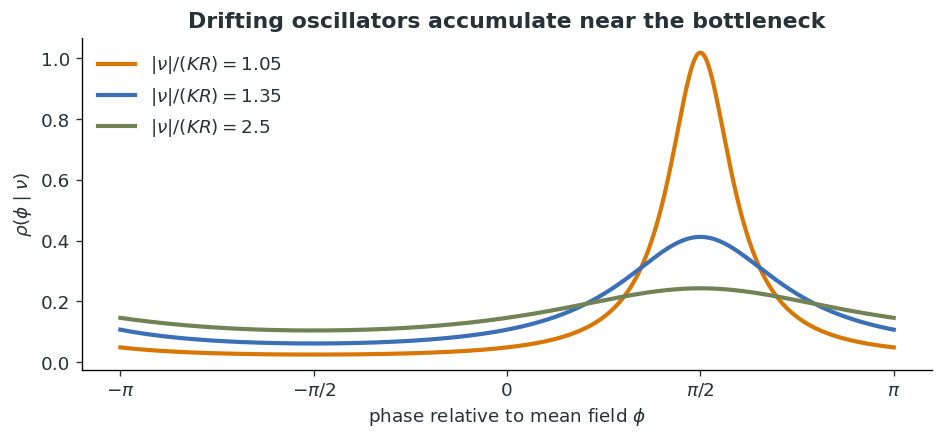

In [19]:
phi = np.linspace(-np.pi, np.pi, 900)
ratios = [1.05, 1.35, 2.50]

fig, ax = plt.subplots(figsize=(8, 3.8))
for ratio, color in zip(ratios, [ORANGE, BLUE, OLIVE]):
    density = np.sqrt(ratio**2 - 1) / (
        2 * np.pi * np.abs(ratio - np.sin(phi))
    )
    ax.plot(phi, density, lw=2.5, color=color, label=rf"$|\nu|/(KR)={ratio:g}$")
ax.set(
    xlabel=r"phase relative to mean field $\phi$",
    ylabel=r"$\rho(\phi\mid\nu)$",
    xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    xticklabels=[r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"],
    title="Drifting oscillators accumulate near the bottleneck",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Drifting contributions cancel

For symmetric $g(\Omega+\nu)=g(\Omega-\nu)$:

$$
\left\langle e^{i\phi}\right\rangle_\nu
=
iA(\nu),
\qquad
A(-\nu)=-A(\nu)
$$

$$
Z_{\mathrm{drift}}=0
$$


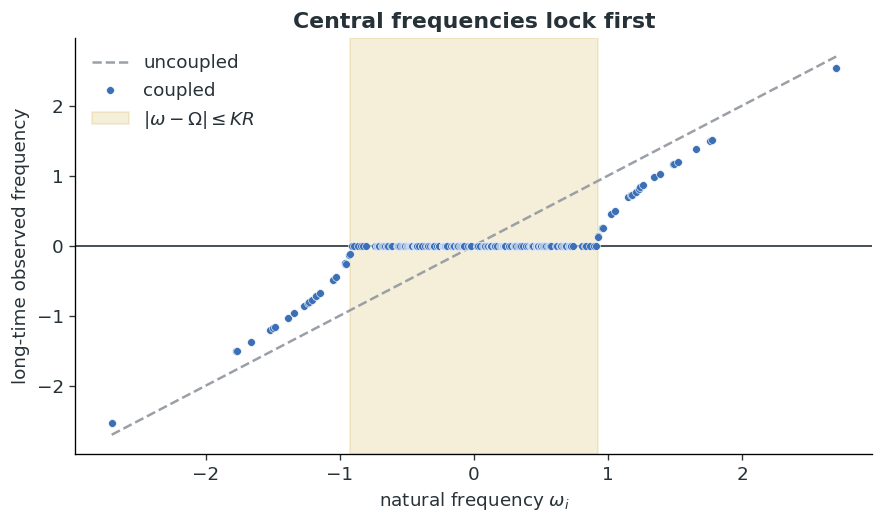

In [20]:
ordered_frequencies = np.sort(natural_frequencies)
partial_K = 1.35
times, phases = simulate_kuramoto(
    ordered_frequencies,
    partial_K,
    rng.uniform(-np.pi, np.pi, ordered_frequencies.size),
    t_end=150,
    dt=0.02,
    save_every=10,
)
mean_observed_frequency = observed_frequencies(
    times, phases, tail_fraction=0.45
)
tail_coherence = np.abs(order_parameter(phases, axis=1))
mean_R = tail_coherence[int(0.55 * tail_coherence.size):].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    ordered_frequencies,
    ordered_frequencies,
    color=GREY,
    lw=1.5,
    ls="--",
    label="uncoupled",
)
ax.scatter(
    ordered_frequencies,
    mean_observed_frequency,
    s=22,
    facecolor=BLUE,
    edgecolor="white",
    linewidth=0.35,
    label="coupled",
    zorder=3,
)
ax.axhline(0, color=INK, lw=1)
ax.axvspan(
    -partial_K * mean_R,
    partial_K * mean_R,
    color=GOLD,
    alpha=0.18,
    label=r"$|\omega-\Omega|\leq KR$",
)
ax.set(
    xlabel=r"natural frequency $\omega_i$",
    ylabel="long-time observed frequency",
    title="Central frequencies lock first",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Locked contribution to $R$

Opposite-frequency locked pairs cancel transverse to $\psi$ and add along $\psi$.

$$
R
=
\int_{-KR}^{KR}
\sqrt{
1-\left(\frac{\nu}{KR}\right)^2
}
g(\Omega+\nu)\,d\nu
$$

The field determines who locks.  
The locked population determines the field.


## Self-consistency equation

With $\nu=KR\sin\phi$:

$$
1
=
K\int_{-\pi/2}^{\pi/2}
\cos^2\phi\,
g(\Omega+KR\sin\phi)\,d\phi
$$


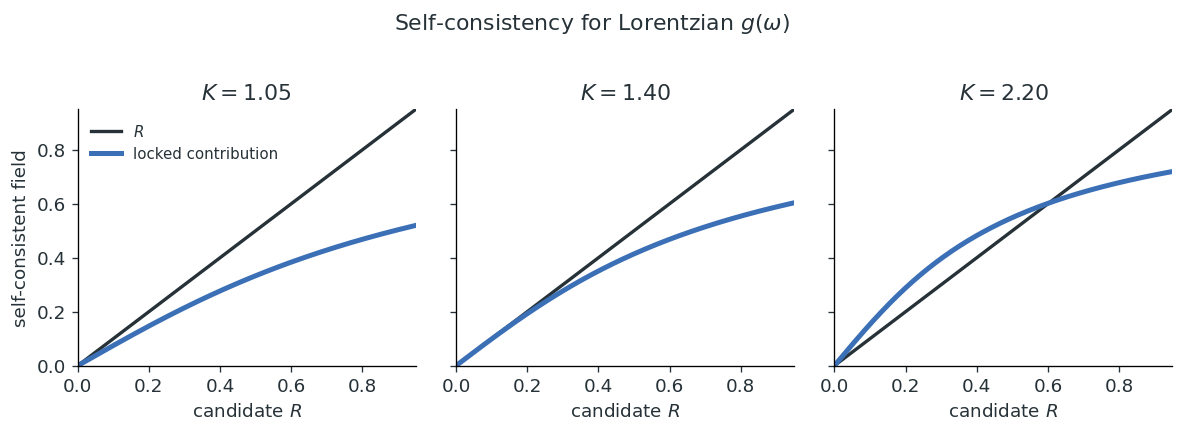

In [21]:
gamma = 0.70
critical_coupling = 2 * gamma
candidate_R = np.linspace(0, 0.95, 350)
scaled_frequency = np.linspace(-1, 1, 2500)
semicircle = np.sqrt(1 - scaled_frequency**2)

def locked_contribution(R_values, coupling):
    values = []
    for coherence in R_values:
        if coherence == 0:
            values.append(0.0)
            continue
        nu = coupling * coherence * scaled_frequency
        density = gamma / (np.pi * (nu**2 + gamma**2))
        integral = coupling * coherence * np.trapezoid(
            semicircle * density, scaled_frequency
        )
        values.append(integral)
    return np.asarray(values)

coupling_examples = [1.05, critical_coupling, 2.20]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharex=True, sharey=True)
for ax, coupling in zip(axes, coupling_examples):
    rhs = locked_contribution(candidate_R, coupling)
    ax.plot(candidate_R, candidate_R, color=INK, lw=2, label=r"$R$")
    ax.plot(candidate_R, rhs, color=BLUE, lw=3, label="locked contribution")
    ax.set(
        xlabel="candidate $R$",
        xlim=(0, 0.95),
        ylim=(0, 0.95),
        title=rf"$K={coupling:.2f}$",
    )
axes[0].set_ylabel("self-consistent field")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle(r"Self-consistency for Lorentzian $g(\omega)$", y=1.02)
fig.tight_layout()
plt.show()


## Onset of collective synchronization

At onset, $R\rightarrow0^+$:

$$
1
=
K_c g(\Omega)
\int_{-\pi/2}^{\pi/2}\cos^2\phi\,d\phi
=
K_c g(\Omega)\frac{\pi}{2}
$$

$$
\boxed{
K_c=\frac{2}{\pi g(\Omega)}
}
$$


## Lorentzian frequencies

$$
g(\omega)
=
\frac{\gamma}
{\pi[(\omega-\Omega)^2+\gamma^2]}
$$

$$
K_c=2\gamma,
\qquad
R=\sqrt{1-\frac{K_c}{K}}
\quad(K\ge K_c)
$$


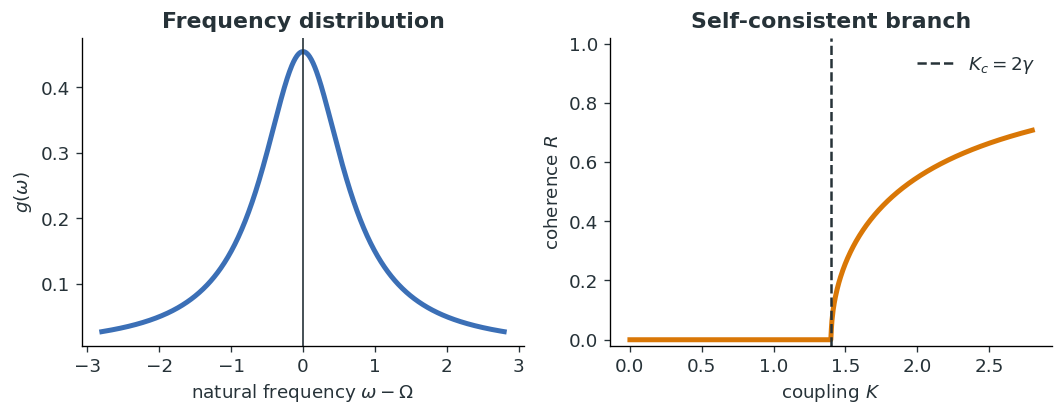

In [22]:
omega_axis = np.linspace(-4 * gamma, 4 * gamma, 700)
frequency_density = gamma / (
    np.pi * (omega_axis**2 + gamma**2)
)
coupling_axis = np.linspace(0, 4 * gamma, 700)
coherence_branch = np.zeros_like(coupling_axis)
above = coupling_axis >= critical_coupling
coherence_branch[above] = np.sqrt(
    1 - critical_coupling / coupling_axis[above]
)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].plot(omega_axis, frequency_density, color=BLUE, lw=3)
axes[0].axvline(0, color=INK, lw=1)
axes[0].set(
    xlabel=r"natural frequency $\omega-\Omega$",
    ylabel=r"$g(\omega)$",
    title="Frequency distribution",
)

axes[1].plot(coupling_axis, coherence_branch, color=ORANGE, lw=3)
axes[1].axvline(
    critical_coupling,
    color=INK,
    lw=1.5,
    ls="--",
    label=r"$K_c=2\gamma$",
)
axes[1].set(
    xlabel="coupling $K$",
    ylabel="coherence $R$",
    ylim=(-0.02, 1.02),
    title="Self-consistent branch",
)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()


## Pair dynamics reappear in the population

Pair:

$$
\dot\Delta
=
\Delta\omega-K\sin\Delta
$$

Population in the rotating mean field:

$$
\dot\phi_i
=
\nu_i-KR\sin\phi_i
$$

Self-consistency determines $R$.


## Kuramoto assumptions

| Assumption | Consequence |
| --- | --- |
| Stable phase oscillators | No amplitude dynamics |
| Weak first-harmonic interaction | Sine coupling |
| Equal all-to-all coupling | One global mean field |
| Static natural frequencies | Fixed heterogeneity |
| No external drive | Synchrony is self-generated |


## Beyond the minimal model

| Change | Dynamics |
| --- | --- |
| Phase lag | Frustration and collective rotation |
| Higher harmonics | Multiple locked phases and clusters |
| Bimodal $g(\omega)$ | Counter-rotating groups and standing waves |
| Noise | Stochastic slips and broadened locking |
| Inertia or delay | Hysteresis and new instabilities |


## Sources

- Yoshiki Kuramoto, [“Self-entrainment of a population of coupled non-linear oscillators”](https://doi.org/10.1007/BFb0013365) (1975).
- Steven H. Strogatz, [“From Kuramoto to Crawford”](https://doi.org/10.1016/S0167-2789(00)00094-4) (2000).
- Juan A. Acebrón *et al.*, [“The Kuramoto model: A simple paradigm for synchronization phenomena”](https://doi.org/10.1103/RevModPhys.77.137) (2005).
- Robert Adler, [“A study of locking phenomena in oscillators”](https://doi.org/10.1109/JRPROC.1946.229930) (1946).
